# Laboratorium 6: Kwadratury
Rozwiązanie zadań dotyczących całkowania numerycznego.

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
import scipy.special as special

def f(x):
    return 4.0 / (1.0 + x**2)

exact_pi = np.pi

def relative_error(approx):
    return np.abs((approx - exact_pi) / exact_pi)

### Zadanie 1: Metody prostokątów, trapezów i Simpsona

Wartości h_min:
Prostokąty: h_min = 1.19e-07, błąd = 7.07e-16
Trapezy:    h_min = 1.19e-07, błąd = 2.54e-15
Simpson:    h_min = 3.91e-03, błąd = 0.00e+00

Empiryczny rząd zbieżności (średnia z pierwszych 5 iteracji):
Prostokąty: 2.00 (teoria: 2)
Trapezy:    2.00 (teoria: 2)
Simpson:    6.75 (teoria: 4)


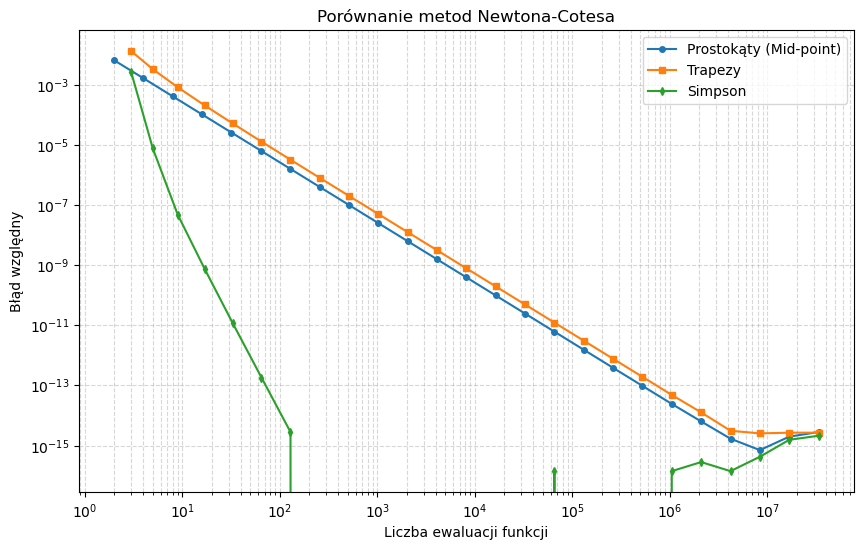

In [42]:
m_values = np.arange(1, 26)
ns = 2**m_values + 1

err_mid = []
evals_mid = []
err_trapz = []
err_simps = []
evals_ts = []

for n in ns:
    x = np.linspace(0, 1, n)
    y = f(x)
    h = 1.0 / (n - 1)
    
    x_mid = np.linspace(h/2, 1 - h/2, n - 1)
    res_mid = h * np.sum(f(x_mid))
    err_mid.append(relative_error(res_mid))
    evals_mid.append(n - 1)
    
    res_trapz = integrate.trapezoid(y, x)
    err_trapz.append(relative_error(res_trapz))
    
    res_simps = integrate.simpson(y, x=x)
    err_simps.append(relative_error(res_simps))
    evals_ts.append(n)

def find_hmin(errors, nodes):
    idx = np.argmin(errors)
    return 1.0 / (nodes[idx] - 1), errors[idx]

hmin_mid, min_err_mid = find_hmin(err_mid, ns)
hmin_trapz, min_err_trapz = find_hmin(err_trapz, ns)
hmin_simps, min_err_simps = find_hmin(err_simps, ns)

print("Wartości h_min:")
print(f"Prostokąty: h_min = {hmin_mid:.2e}, błąd = {min_err_mid:.2e}")
print(f"Trapezy:    h_min = {hmin_trapz:.2e}, błąd = {min_err_trapz:.2e}")
print(f"Simpson:    h_min = {hmin_simps:.2e}, błąd = {min_err_simps:.2e}")

def empirical_order(errors, nodes, steps=5):
    
    h = 1.0 / (np.array(nodes) - 1)
    
    valid_indices = (np.array(errors[:steps]) > 0) & (np.array(errors[1:steps+1]) > 0)
    
    if np.any(valid_indices):
        orders = np.log(np.array(errors[1:steps+1])[valid_indices] / np.array(errors[:steps])[valid_indices]) / \
                 np.log(h[1:steps+1][valid_indices] / h[:steps][valid_indices])
        return np.mean(orders)
    else:
        return np.nan

print("\nEmpiryczny rząd zbieżności (średnia z pierwszych 5 iteracji):")
print(f"Prostokąty: {empirical_order(err_mid, ns):.2f} (teoria: 2)")
print(f"Trapezy:    {empirical_order(err_trapz, ns):.2f} (teoria: 2)")
print(f"Simpson:    {empirical_order(err_simps, ns):.2f} (teoria: 4)")

plt.figure(figsize=(10, 6))
plt.plot(evals_mid, err_mid, 'C0o-', markersize=4, label="Prostokąty (Mid-point)")
plt.plot(evals_ts, err_trapz, 'C1s-', markersize=4, label="Trapezy")
plt.plot(evals_ts, err_simps, 'C2d-', markersize=4, label="Simpson")

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Liczba ewaluacji funkcji")
plt.ylabel("Błąd względny")
plt.title("Porównanie metod Newtona-Cotesa")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

### Zadanie 2: Kwadratura Gaussa-Legendre'a

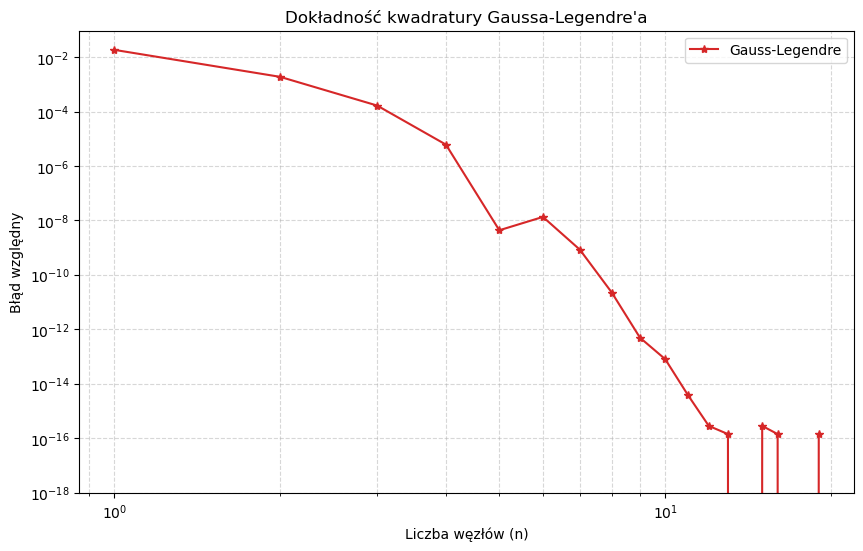

In [43]:

ns_gauss = np.arange(1, 20)
err_gauss = []
evals_gauss = []

for n in ns_gauss:
    roots, weights = special.roots_legendre(n)
    t_roots = 0.5 * roots + 0.5
    t_weights = 0.5 * weights
    res_gauss = np.sum(t_weights * f(t_roots))
    
    err_gauss.append(relative_error(res_gauss))
    evals_gauss.append(n)

plt.figure(figsize=(10, 6))
plt.plot(evals_gauss, err_gauss, 'C3*-', markersize=6, label="Gauss-Legendre")

plt.xscale('log')
plt.yscale('log')
plt.ylim(bottom=1e-18) 
plt.xlabel("Liczba węzłów (n)")
plt.ylabel("Błąd względny")
plt.title("Dokładność kwadratury Gaussa-Legendre'a")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

### Zadanie 3: Metody adaptacyjne

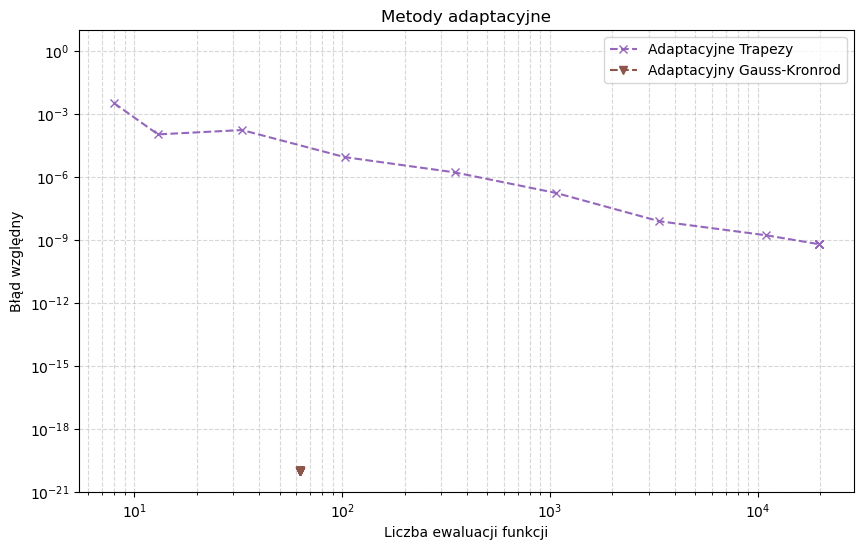

In [57]:

tols = np.logspace(0, -14, 15)
err_adapt_trapz = []
evals_adapt_trapz = []
err_adapt_gk = []
evals_adapt_gk = []

for tol in tols:
    res_t, _, info_t = integrate.quad_vec(f, 0, 1, quadrature='trapezoid', epsabs=tol, full_output=True)
    err_adapt_trapz.append(relative_error(res_t))
    evals_adapt_trapz.append(info_t.neval)
    
    res_gk, _, info_gk = integrate.quad_vec(f, 0, 1, quadrature='gk21', epsabs=tol, full_output=True)
    err_adapt_gk.append(relative_error(res_gk))
    evals_adapt_gk.append(info_gk.neval)
    
plt.figure(figsize=(10, 6))

sort_t = np.argsort(evals_adapt_trapz)
sort_gk = np.argsort(evals_adapt_gk)

plt.plot(np.array(evals_adapt_trapz)[sort_t], 
         np.clip(np.array(err_adapt_trapz)[sort_t], 1e-20, None), 
         'C4x--', label="Adaptacyjne Trapezy")

plt.plot(np.array(evals_adapt_gk)[sort_gk], 
         np.clip(np.array(err_adapt_gk)[sort_gk], 1e-20, None), 
         'C5v--', label="Adaptacyjny Gauss-Kronrod")

plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-21, 1e1)
plt.xlabel("Liczba ewaluacji funkcji")
plt.ylabel("Błąd względny")
plt.title("Metody adaptacyjne")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

### Zadanie 4: Metoda Monte Carlo

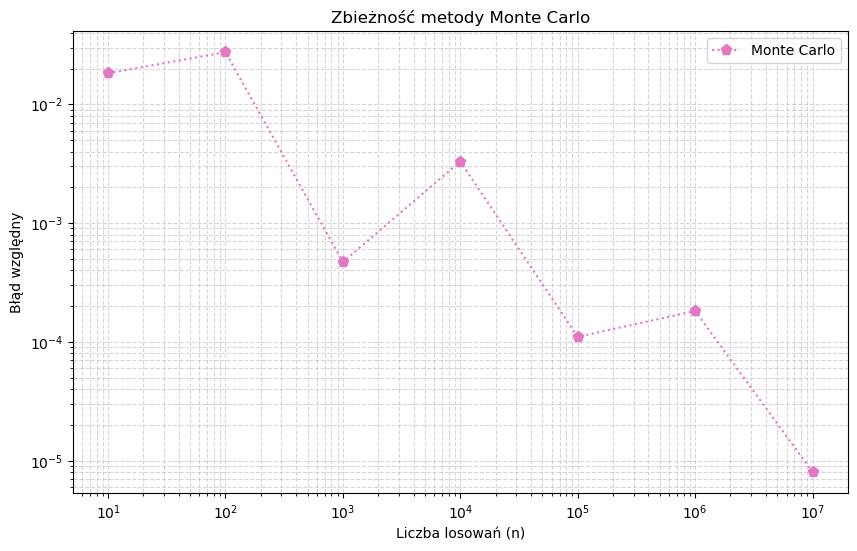

In [45]:
ns_mc = np.logspace(1, 7, 7, dtype=int)
err_mc = []

np.random.seed(42)
for n in ns_mc:
    x_mc = np.random.uniform(0, 1, n)
    res_mc = np.mean(f(x_mc))
    err_mc.append(relative_error(res_mc))
    
plt.figure(figsize=(10, 6))
plt.plot(ns_mc, err_mc, 'C6p:', markersize=8, label="Monte Carlo")

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Liczba losowań (n)")
plt.ylabel("Błąd względny")
plt.title("Zbieżność metody Monte Carlo")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

### Wykres podsumowujący wszystkie metody

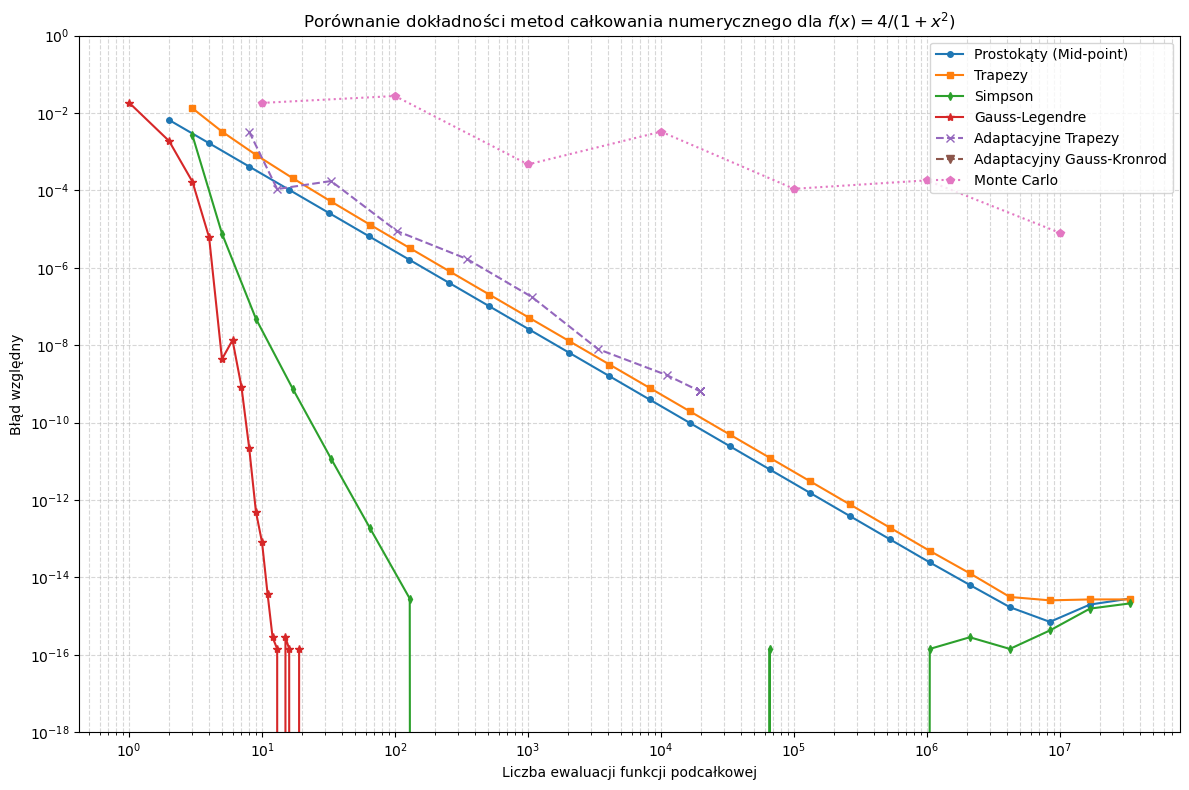

In [46]:
plt.figure(figsize=(12, 8))

plt.plot(evals_mid, err_mid, 'o-', markersize=4, label="Prostokąty (Mid-point)")
plt.plot(evals_ts, err_trapz, 's-', markersize=4, label="Trapezy")
plt.plot(evals_ts, err_simps, 'd-', markersize=4, label="Simpson")
plt.plot(evals_gauss, err_gauss, '*-', markersize=6, label="Gauss-Legendre")

sort_t = np.argsort(evals_adapt_trapz)
plt.plot(np.array(evals_adapt_trapz)[sort_t], np.array(err_adapt_trapz)[sort_t], 'x--', label="Adaptacyjne Trapezy")

sort_gk = np.argsort(evals_adapt_gk)
plt.plot(np.array(evals_adapt_gk)[sort_gk], np.array(err_adapt_gk)[sort_gk], 'v--', label="Adaptacyjny Gauss-Kronrod")

plt.plot(ns_mc, err_mc, 'p:', markersize=6, label="Monte Carlo")

plt.xscale('log')
plt.yscale('log')
plt.ylim(bottom=1e-18, top=1e0)

plt.xlabel("Liczba ewaluacji funkcji podcałkowej")
plt.ylabel("Błąd względny")
plt.title("Porównanie dokładności metod całkowania numerycznego dla $f(x)=4/(1+x^2)$")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()